# SemEval-2026 Task 12: deBERTa Ranking Performance Analysis
Analyzing the ranking performance based on `Logit_Score`

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json

In [44]:
# Load the dataset
data_path = '../../retriever+reasoning/core/test_error_analysis.csv'
df = pd.read_csv(data_path)

# Preprocess to identify if an option is correct
df['Golden_Answers_List'] = df['Golden_Answers'].apply(lambda x: [ans.strip() for ans in str(x).split(',')])
df['Is_Correct'] = df.apply(lambda row: row['Option'] in row['Golden_Answers_List'], axis=1)

# Display the first few rows to understand the structure
df[['Question_ID', 'Option', 'Golden_Answers', 'Logit_Score']].head()

,Question_ID,Option,Golden_Answers,Logit_Score
0,q-2420,A,A,0.9998
1,q-2420,B,A,0.0013
2,q-2420,C,A,0.0001
3,q-2420,D,A,0.0003
4,q-2421,A,A,0.9998


In [45]:
reference_path = '../../semeval2026-task12-dataset/test_data/questions.jsonl'
option_map = {}
with open(reference_path, 'r') as f:
    for line in f:
        if line.strip():
            ref = json.loads(line)
            option_map[f"{ref['id']}-A"] = ref['option_A']
            option_map[f"{ref['id']}-B"] = ref['option_B']
            option_map[f"{ref['id']}-C"] = ref['option_C']
            option_map[f"{ref['id']}-D"] = ref['option_D']

df['option_text'] = (df['Question_ID'] + '-' + df['Option']).map(option_map)

In [46]:
irrelevant_pattern = "None of the others are correct causes."

irrelevant_question = df[df.option_text.str.contains(irrelevant_pattern) & df.Is_Correct].Question_ID.tolist()
df = df[~df.Question_ID.isin(irrelevant_question)].copy()
df = df[~df.option_text.str.contains(irrelevant_pattern)].copy()

print(f"After filtering no-answers questions, we have {df.Question_ID.nunique()} questions.")

After filtering no-answers questions, we have 386 questions.


In [47]:
def calculate_ranking_metrics(group):
    # Sort the options for each question by Logit_Score in descending order
    sorted_group = group.sort_values(by='Logit_Score', ascending=False).reset_index(drop=True)
    
    # Get the 1-based ranks of the correct options
    correct_ranks = sorted_group.index[sorted_group['Is_Correct']].tolist()
    correct_ranks = [r + 1 for r in correct_ranks]
    
    if not correct_ranks:
        return pd.Series({'MRR': 0.0, 'Hit@1': 0.0, 'Hit@2': 0.0, 'Hit@3': 0.0})
        
    # Best rank among the correct options
    best_rank = correct_ranks[0]
    
    mrr = 1.0 / best_rank
    p_1 = 1.0 if best_rank == 1 else 0.0
    
    return pd.Series({'MRR': mrr, 'Precision@1': p_1})

# Apply the metric calculation per question
metrics_df = df.groupby('Question_ID').apply(calculate_ranking_metrics).reset_index()

metrics_summary = metrics_df[['MRR', 'Precision@1']].mean()
print(metrics_summary)

MRR            0.903929
Precision@1    0.841969
dtype: float64


## Visualizations

In [48]:
all_golden_sims = df[df.Is_Correct].Logit_Score.to_list()
all_non_golden_sims = df[~df.Is_Correct].Logit_Score.to_list()

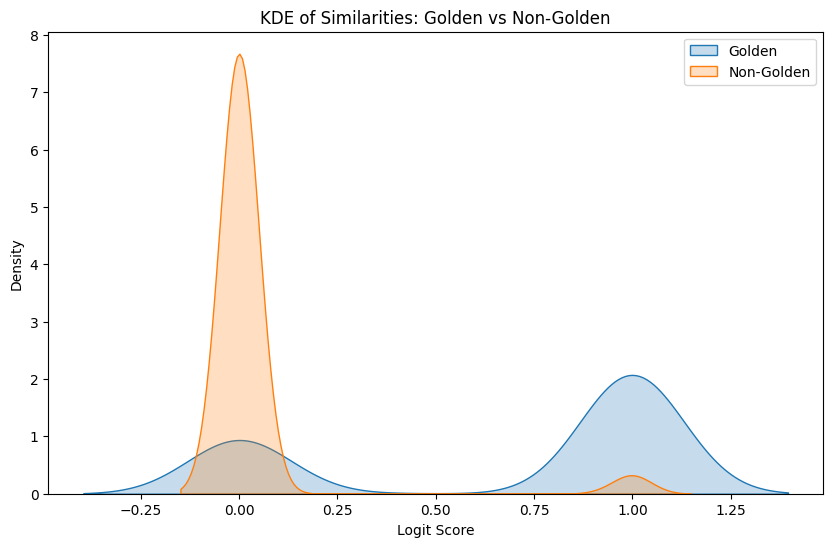

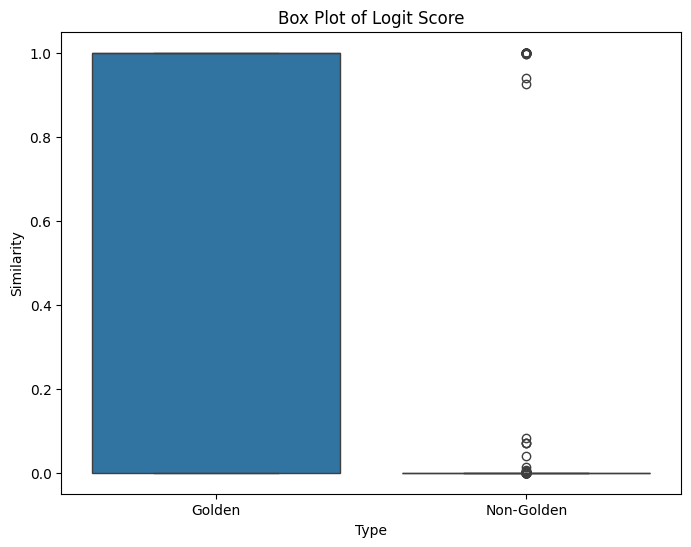

In [51]:
plt.figure(figsize=(10, 6))
sns.kdeplot(all_golden_sims, label='Golden', fill=True)
sns.kdeplot(all_non_golden_sims, label='Non-Golden', fill=True)
plt.title('KDE of Similarities: Golden vs Non-Golden')
plt.xlabel('Logit Score')
plt.legend()
plt.show()

stats_df = pd.DataFrame({
    'Similarity': all_golden_sims + all_non_golden_sims,
    'Type': ['Golden'] * len(all_golden_sims) + ['Non-Golden'] * len(all_non_golden_sims)
})

plt.figure(figsize=(8, 6))
sns.boxplot(data=stats_df, x='Type', y='Similarity')
plt.title('Box Plot of Logit Score')
plt.show()